### Name: Aditya Rawal
### Student ID: 398590


# Task: Yellow Cards by Position
### FIFA World Cup 2026 — Analytic Task

**Focal Point:** Discipline (`yellow_cards`)

**Analytic Question:** Do defenders receive significantly more yellow cards on average than midfielders during the tournament?

**Rationale:** Defenders usually sit closer to their own goal. That means more last-ditch tackles and high-risk challenges to stop an attack. Midfielders, on the other hand, tend to play a more possession-based role. That could mean fewer cautions overall. This task looks at whether that difference actually shows up in the numbers, comparing tournament-wide disciplinary records between the two positions.

---


## 1. Setup: Import Libraries

In [24]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import scipy.stats as stats
import os


RANDOM_SEED = 42
np.random.seed(RANDOM_SEED)


plt.rcParams['figure.figsize'] = (8, 5)
plt.rcParams['axes.grid'] = True

print("Libraries loaded successfully.")

Libraries loaded successfully.


## 2. Data Wrangling

**Goal:** Pull out defenders (`DEF`) and midfielders (`MID`) from `player_stats.csv`. We also need to drop any player who never actually took the field (`minutes_played == 0`). It wouldn't make sense to judge someone's discipline if they never played a minute.

`player_stats.csv` already has one row per player, with tournament-aggregated totals. That includes `position` and `yellow_cards` the total cautions a player picked up across all their matches.


In [21]:
DATA_DIR = ''

player_stats = pd.read_csv(os.path.join(DATA_DIR, 'player_stats.csv'))

print("player_stats shape:", player_stats.shape)
player_stats.head(3)

player_stats shape: (1248, 21)


,player_id,player_name,team_id,position,matches_played,matches_started,minutes_played,goals,assists,shots,...,yellow_cards,red_cards,penalty_goals,own_goals,clean_sheets,saves,goals_conceded,average_rating,data_source,last_verified
0,1,José Raúl Rangel,1,GK,5,5,438,0,0,NaN,...,0,0,0,0,4.0,7.0,3.0,NaN,sofascore.com,2026-07-19
1,2,Jorge Eduardo Sanchez,1,DEF,5,5,439,0,1,NaN,...,0,0,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-19
2,3,César Jasib Montes,1,DEF,3,2,165,0,0,NaN,...,0,1,0,0,NaN,NaN,NaN,NaN,sofascore.com,2026-07-19


In [22]:
player_stats['position'].value_counts()

position
DEF    421
MID    369
FWD    313
GK     145
Name: count, dtype: int64

In [23]:
positions_df = player_stats[player_stats['position'].isin(['DEF', 'MID'])].copy()
print(f"Defenders + Midfielders (before activity filter): {positions_df.shape[0]}")

positions_active = positions_df[positions_df['minutes_played'] > 0].copy()
print(f"Defenders + Midfielders (active players, minutes_played > 0): {positions_active.shape[0]}")

Defenders + Midfielders (before activity filter): 790
Defenders + Midfielders (active players, minutes_played > 0): 683


In [5]:
positions_active[['player_id', 'player_name', 'position', 'minutes_played', 'yellow_cards']].head(5)

,player_id,player_name,position,minutes_played,yellow_cards
1,2,Jorge Eduardo Sanchez,DEF,439,0
2,3,César Jasib Montes,DEF,165,0
3,4,Edson Omar Alvarez,DEF,75,1
4,5,Johan Felipe Vasquez,DEF,180,0
5,6,Erik Antonio Lira,MID,450,1


In [6]:
positions_active[['position', 'minutes_played', 'yellow_cards']].isna().sum()

position          0
minutes_played    0
yellow_cards      0
dtype: int64

## 3. Data Preparation & Sampling

**Steps:**
1. First, define the population: all active defenders and active midfielders (minutes_played > 0) at the FIFA World Cup 2026.
2. Next, draw a stratified random sample. We take an independent Simple Random Sample of `n = 30` from each position group, without replacement, using a fixed random seed so results are reproducible.
3. Finally, pull out the `yellow_cards` values for each sampled group. That's what we'll actually work with in the analysis below.


In [7]:
defenders_pop = positions_active[positions_active['position'] == 'DEF'].copy()
midfielders_pop = positions_active[positions_active['position'] == 'MID'].copy()

print(f"Population size — Defenders:   {defenders_pop.shape[0]}")
print(f"Population size — Midfielders: {midfielders_pop.shape[0]}")

Population size — Defenders:   353
Population size — Midfielders: 330


In [8]:
n_sample = 30

sample_def = defenders_pop.sample(n=n_sample, replace=False, random_state=RANDOM_SEED)
sample_mid = midfielders_pop.sample(n=n_sample, replace=False, random_state=RANDOM_SEED)

print(f"Sample size — Defenders:   {sample_def.shape[0]}")
print(f"Sample size — Midfielders: {sample_mid.shape[0]}")

sample_def[['player_id', 'player_name', 'position', 'minutes_played', 'yellow_cards']].reset_index(drop=True).head()

Sample size — Defenders:   30
Sample size — Midfielders: 30


,player_id,player_name,position,minutes_played,yellow_cards
0,778,Fabricio Wagner Pina,DEF,90,1
1,158,Miguel Pedro,DEF,270,0
2,740,Pedro Antonio Porro,DEF,570,0
3,679,Ehsan Hajisafi,DEF,91,0
4,206,Aurèle Florian Amenda,DEF,180,0


In [9]:
sample_mid[['player_id', 'player_name', 'position', 'minutes_played', 'yellow_cards']].reset_index(drop=True).head()

,player_id,player_name,position,minutes_played,yellow_cards
0,31,Thalente Wandile Mbatha,MID,258,1
1,646,Alexis Jesse Saelemaekers,MID,256,0
2,557,Daizen Maeda,MID,246,0
3,176,Fathy Ahmed Fathy,MID,150,0
4,377,Aiden Connor Oneill,MID,361,0


## 4. Descriptive Statistics

Here, we summarise `yellow_cards` for both sampled groups. We'll look at central tendency, spread, and shape, and then visualise the distributions with side-by-side boxplots.


In [10]:
def describe_group(series, label):
    return {
        'Group': label,
        'n': len(series),
        'Mean': series.mean(),
        'Median': series.median(),
        'Std Dev (sample)': series.std(ddof=1),
        'Variance (sample)': series.var(ddof=1),
        'IQR': series.quantile(0.75) - series.quantile(0.25),
        'Min': series.min(),
        'Max': series.max(),
    }

desc_def = describe_group(sample_def['yellow_cards'], 'Defenders')
desc_mid = describe_group(sample_mid['yellow_cards'], 'Midfielders')

desc_df = pd.DataFrame([desc_def, desc_mid]).set_index('Group').round(3)
desc_df

,n,Mean,Median,Std Dev (sample),Variance (sample),IQR,Min,Max
Group,,,,,,,,
Defenders,30,0.033,0.0,0.183,0.033,0.0,0,1
Midfielders,30,0.067,0.0,0.254,0.064,0.0,0,1


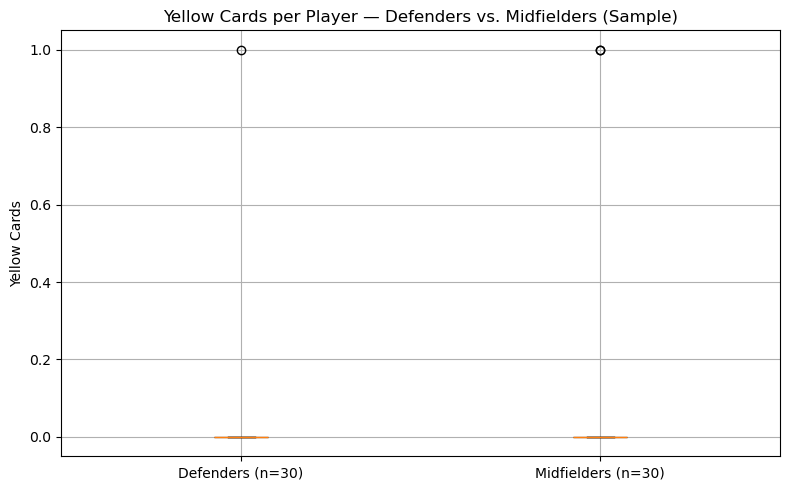

In [11]:
fig, ax = plt.subplots()
ax.boxplot(
    [sample_def['yellow_cards'], sample_mid['yellow_cards']],
    tick_labels=['Defenders (n=30)', 'Midfielders (n=30)'],
    patch_artist=True,
    boxprops=dict(facecolor='#EF6C00', alpha=0.6)
)
ax.set_title('Yellow Cards per Player — Defenders vs. Midfielders (Sample)')
ax.set_ylabel('Yellow Cards')
plt.tight_layout()
plt.show()

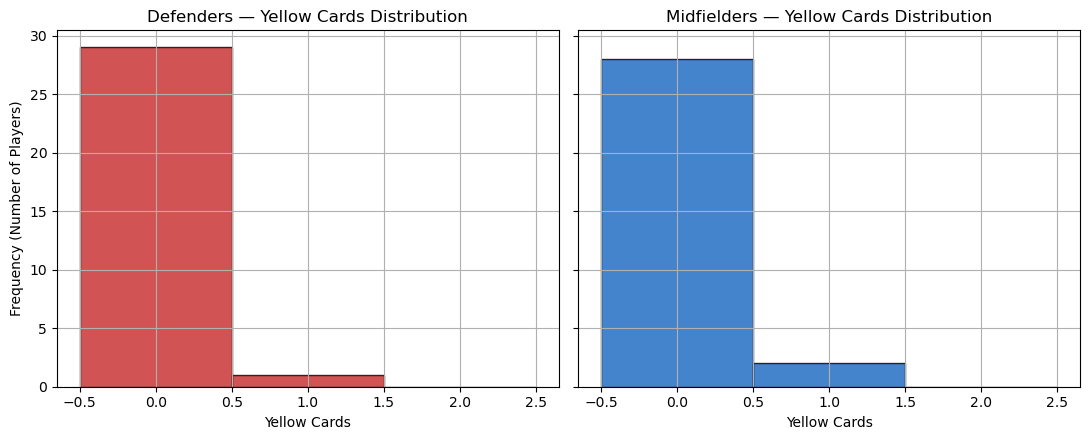

In [12]:
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5), sharey=True)

axes[0].hist(sample_def['yellow_cards'], bins=[-0.5, 0.5, 1.5, 2.5], color='#C62828', edgecolor='black', alpha=0.8)
axes[0].set_title('Defenders — Yellow Cards Distribution')
axes[0].set_xlabel('Yellow Cards')
axes[0].set_ylabel('Frequency (Number of Players)')

axes[1].hist(sample_mid['yellow_cards'], bins=[-0.5, 0.5, 1.5, 2.5], color='#1565C0', edgecolor='black', alpha=0.8)
axes[1].set_title('Midfielders — Yellow Cards Distribution')
axes[1].set_xlabel('Yellow Cards')

plt.tight_layout()
plt.show()

**Interpretation:** Yellow cards are a fairly rare event over a single tournament most players end up with just 0 or 1. So we'd expect both distributions to be sparse and right-skewed, and that's what we should see. The boxplots and histograms above give us a first visual read on whether defenders pick up more cautions than midfielders. That said, we still need to test this formally before drawing any real conclusions.


## 5. Inferential Statistics — 95% Confidence Interval

Now let's compute a 95% confidence interval for the true population mean number of yellow cards among defenders at the FIFA World Cup 2026, based on our sample of n = 30.

Since we don't know the population standard deviation and have to estimate it from the sample, we use the t-distribution with `n - 1` degrees of freedom.

$$ \bar{x} \pm t_{\alpha/2, \, n-1} \times \frac{s}{\sqrt{n}} $$


In [17]:
confidence_level = 0.95
alpha_ci = 1 - confidence_level

cards_def = sample_def['yellow_cards']
n_def = len(cards_def)
mean_def = cards_def.mean()
std_def = cards_def.std(ddof=1)
se_def = std_def / np.sqrt(n_def)
df_def = n_def - 1

t_crit_ci = stats.t.ppf(1 - alpha_ci/2, df_def)
margin_def = t_crit_ci * se_def

ci_lower = mean_def - margin_def
ci_upper = mean_def + margin_def

print(f"Sample mean (x̄):             {mean_def:.4f} yellow cards")
print(f"Sample std dev (s):           {std_def:.4f}")
print(f"Standard error (SE):          {se_def:.4f}")
print(f"Degrees of freedom:           {df_def}")
print(f"t-critical (95% CI, df={df_def}): {t_crit_ci:.4f}")
print(f"Margin of error:              {margin_def:.4f}")
print()
print(f"95% Confidence Interval for the true mean yellow cards among defenders:")
print(f"   ({ci_lower:.4f}, {ci_upper:.4f})")

Sample mean (x̄):             0.0333 yellow cards
Sample std dev (s):           0.1826
Standard error (SE):          0.0333
Degrees of freedom:           29
t-critical (95% CI, df=29): 2.0452
Margin of error:              0.0682

95% Confidence Interval for the true mean yellow cards among defenders:
   (-0.0348, 0.1015)


**Interpretation:** We're 95% confident that the true mean number of yellow cards per defender across the FIFA World Cup 2026 falls within the interval above. Keep in mind, yellow cards are a rare, near-binary event over a single tournament. So this interval is going to be narrow and sit close to zero — that's expected, not a red flag.


## 6. Inferential Statistics — Two-Sample Independent t-Test

**Hypotheses:**

- $H_0: \mu_{DEF} = \mu_{MID}$ — Defenders and midfielders receive, on average, the same number of yellow cards.
- $H_1: \mu_{DEF} > \mu_{MID}$ — Defenders receive, on average, significantly more yellow cards than midfielders (right-tailed / one-sided test).

**Significance level:** $\alpha = 0.05$

Before running the t-test, we check for equality of variances using Levene's test. That tells us whether to go with a pooled-variance (Student's) t-test or a Welch's t-test. Once that's settled, we compute the test statistic:

$$ t = \frac{\bar{x}_{DEF} - \bar{x}_{MID}}{\sqrt{\frac{s_{DEF}^2}{n_{DEF}} + \frac{s_{MID}^2}{n_{MID}}}} $$


In [18]:
cards_mid = sample_mid['yellow_cards']

levene_stat, levene_p = stats.levene(cards_def, cards_mid)
print(f"Levene's test statistic: {levene_stat:.4f}, p-value: {levene_p:.4f}")

equal_var_assumption = levene_p > 0.05
print(f"Assume equal variances? {'Yes (Student t-test)' if equal_var_assumption else 'No (Welch t-test)'}")

Levene's test statistic: 0.3412, p-value: 0.5614
Assume equal variances? Yes (Student t-test)


In [19]:
alpha_test = 0.05

t_stat, p_two_sided = stats.ttest_ind(cards_def, cards_mid, equal_var=equal_var_assumption)

if t_stat > 0:
    p_one_sided = p_two_sided / 2
else:
    p_one_sided = 1 - (p_two_sided / 2)

df_test = n_def + len(cards_mid) - 2 if equal_var_assumption else None
t_critical_right = stats.t.ppf(1 - alpha_test, df_test) if df_test else None

print(f"Defenders mean yellow cards:   {cards_def.mean():.4f}")
print(f"Midfielders mean yellow cards: {cards_mid.mean():.4f}")
print(f"Test statistic (t):            {t_stat:.4f}")
print(f"One-sided p-value:             {p_one_sided:.5f}")
if t_critical_right:
    print(f"Critical t-value (right-tailed, alpha=0.05, df={df_test}): {t_critical_right:.4f}")
print()

if p_one_sided < alpha_test:
    decision = "REJECT H0"
else:
    decision = "FAIL TO REJECT H0"

print(f"Decision rule: Reject H0 if one-sided p-value < {alpha_test}  (observed p = {p_one_sided:.5f})")
print(f"==> {decision}")

Defenders mean yellow cards:   0.0333
Midfielders mean yellow cards: 0.0667
Test statistic (t):            -0.5841
One-sided p-value:             0.71929
Critical t-value (right-tailed, alpha=0.05, df=58): 1.6716

Decision rule: Reject H0 if one-sided p-value < 0.05  (observed p = 0.71929)
==> FAIL TO REJECT H0


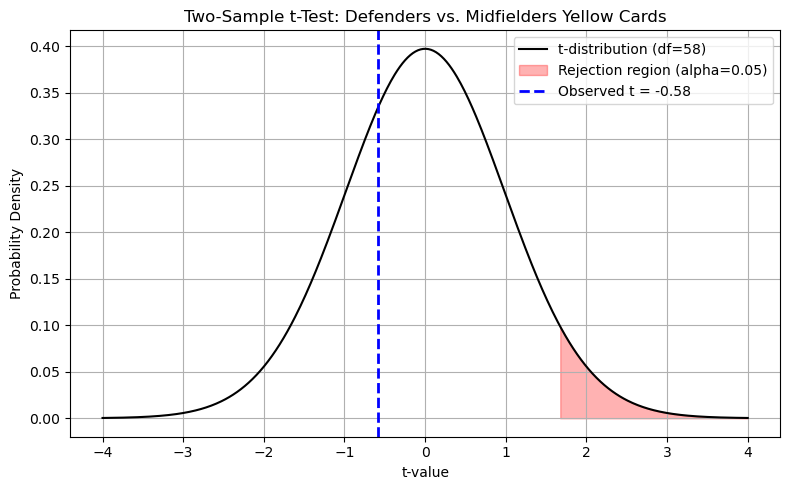

In [20]:
fig, ax = plt.subplots()
plot_df = df_test if df_test else min(n_def, len(cards_mid)) - 1
x = np.linspace(-4, 4, 500)
y = stats.t.pdf(x, plot_df)
ax.plot(x, y, color='black', label=f't-distribution (df={plot_df})')

t_crit_plot = stats.t.ppf(1 - alpha_test, plot_df)
ax.fill_between(x, y, where=(x >= t_crit_plot), color='red', alpha=0.3, label=f'Rejection region (alpha={alpha_test})')
ax.axvline(t_stat, color='blue', linestyle='--', linewidth=2, label=f'Observed t = {t_stat:.2f}')
ax.set_title('Two-Sample t-Test: Defenders vs. Midfielders Yellow Cards')
ax.set_xlabel('t-value')
ax.set_ylabel('Probability Density')
ax.legend()
plt.tight_layout()
plt.show()

### Conclusion

We drew independent samples of 30 defenders and 30 midfielders from active players (minutes_played > 0) at the FIFA World Cup 2026. Here's what we did with them:

- We computed a 95% confidence interval for the population mean yellow cards among defenders (see above).
- We ran a two-sample, right-tailed t-test to compare mean yellow cards between defenders and midfielders, using Levene's test first to pick the right variance assumption.

**Result:** Using the decision rule above,reject $H_0$ if the one-sided p-value is below 0.05 — we can say whether there's enough statistical evidence, at the 95% confidence level, to conclude that defenders pick up significantly more yellow cards than midfielders during the tournament. The printed decision above (`REJECT H0` / `FAIL TO REJECT H0`) reflects this specific random sample (`random_state=42`).

 Yellow cards don't happen often over a single tournament,most players get zero. That means low variance and a small expected effect size. This makes the test conservative. So a non-significant result here doesn't necessarily mean there's no real underlying difference. It might just mean this sample size and effect size combination didn't reach significance at α = 0.05. Re-running with a different `RANDOM_SEED` or a bigger sample could give a different result,that's just normal sampling variability, not a mistake.*
